<h2 style="color:#9D2449; font-family:'Montserrat', sans-serif; font-size:42px; font-weight:700; margin-top:25px; margin-bottom:12px;">
Deducción de un índice de esfuerzo usando entropía de Shannon
</h2>

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Carga de Datos
</h4>

In [62]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# Cargar datos
df = pd.read_csv("Effor_index_MASTER.csv")

# Columna de existencia de costo
df["costo"] = df["TraCosto"].map({"VERDADERO": 1, "FALSO": 0})

#Asignación de niveles de digitalización
mapa_fijo = {
    "nivel 1": 1,
    "nivel 2": 2,
    "nivel 3.1": 3,
    "nivel 3.2": 4,
    "nivel 3.3": 5,
    "nivel 3.4": 6,
    "nivel 3.5": 7,
    "nivel 3.6": 8,
    "nivel 3.7": 9,
    "nivel 3.8": 10,
    "nivel 3.9": 11,
    "nivel 4.1": 12,
    "nivel 4.2": 13,
    "nivel 4.3": 14
}

df["nivel_digitalizacion_numT"] = (
    df["nivel_digitalizacion"]
    .str.lower()
    .str.strip()
    .map(mapa_fijo)
)

#Suponemos falta de digitalización a aquellos trámites que no presentan un nivel
df["nivel_digitalizacion_numT"] = df["nivel_digitalizacion_numT"].fillna(0)
df["nivel_digitalizacion_numT"].value_counts().sort_index()

nivel_digitalizacion_numT
0.0     211
1.0     262
2.0      70
3.0      14
4.0       3
7.0      41
9.0      24
10.0      1
11.0     10
12.0     18
13.0      6
14.0      7
Name: count, dtype: int64

Las variables presentes en trámites y servicios son de cierta categoría. El nivel de digitalización es discreto habiendo solo 14 niveles; los números de formatos y requisitos también son discretos obteniendo un valor dependiendo del trámite; el costo es un valor binario, a fin de cuentas discreto, que determina si existe costo o no del trámite; finalmente, el tiempo, al ser una variable de valores muy grandes, su rango existe entre los 0 y los 518 mil minutos, prácticamente este dato permite cualquier valor en ese intervalo, por ello es posible considerarla como continua.

Para la propuesta de un índice de esfuerzo, se propone el uso de la entropía de Shannon, un valor que determina incertidumbre o dispersión en los datos. Este método utiliza variables discretas y las probabilidades de que exista dicha variable entre el rango de posibles valores, por ello, será necesario poder discretizar el valor del tiempo.

Como los datos de tiempo caen dentro del rango de 0 a 518 mil minutos (1 año aproximadamente) podemos proponer el reescalamiento de dicha variable en un rango más corto utilizando el logaritmo de los valores de tiempo. Como existen tiempos cero entonces sería necesario incluir el término "1+t" para el logaritmo. Podemos asignar el rango de la transformación en deciles.

In [63]:
#A cada trámite que no presenta dato de tiempo, se le asigna el valor de la mediana correspondiente a su dependencia.
def imputar_grupo(x):
    if x.notna().sum() > 5:  # mínimo de datos
        return x.fillna(x.median())
    else:
        return x.fillna(df["Tiempo_en_minutos"].median())

df["Tiempo_en_minutos"] = df.groupby("Dependencia")["Tiempo_en_minutos"].transform(imputar_grupo)

# Transformación log(1 + t)
df["tiempo_log"] = np.log1p(df["Tiempo_en_minutos"])

#Eliminamos dos trámites con datos vacíos
df = df.dropna(subset=["tiempo_log"])

#Agrupamos datos del logaritmo en 8 intervalos de igual tamaño
df["tiempo_bin"] = pd.cut(
    df["tiempo_log"],
    bins=8,
    include_lowest=True
)
df["tiempo_bin"].value_counts().sort_index()

tiempo_bin
(-0.0142, 1.645]      5
(1.645, 3.29]       101
(3.29, 4.934]       115
(4.934, 6.579]       15
(6.579, 8.224]      170
(8.224, 9.869]       95
(9.869, 11.514]     131
(11.514, 13.159]     33
Name: count, dtype: int64

La variable de requisitos contiene de 0 hasta 15 requisitos, implicando 16 categorías individuales, sin embargo, se opta por asignar 5 categorías reales porque algunas existencias de requisitos tienen muy pocas apariciones, casi nulas, entonces podemos agruparlas.

In [ ]:
df["requisitos_bin"] = pd.cut(
    df["CONTEO_NETO"],
    bins=[-1, 1, 3, 6, 10, 15],
    labels=False
)#5 intervalos

df["requisitos_bin"].value_counts().sort_index()

requisitos_bin
0    314
1    209
2     93
3     38
4     11
Name: count, dtype: int64

Se realiza el mismo análisis para la variable de formatos pues tiene comportamiento muy similar

In [ ]:
df["formatos_bin"] = pd.cut(
    df["N_FORMATOS_FINAL"],
    bins=[-1, 0, 1, 2, 3, 12],
    labels=False
)#5 intervalos
df["formatos_bin"].value_counts().sort_index()

formatos_bin
0    305
1    296
2     45
3     12
4      7
Name: count, dtype: int64

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Determinación del índice de complejidad/esfuerzo
</h4>

Creamos la función de entropía y su normalización

In [66]:
def shannon_entropy(series):
    probs = series.value_counts(normalize=True)
    return -np.sum(probs * np.log(probs))

def normalize_entropy(series):
    k = series.nunique()
    H = shannon_entropy(series)
    H_max = np.log(k)
    return H / H_max if H_max > 0 else 0

Realizamos pruebas de cálculo de entropía para las asignaciones de requisitos y formatos para observar las diferencias.

In [67]:
H_requisitos = shannon_entropy(df["CONTEO_NETO"])
H_requisitos_bin = shannon_entropy(df["requisitos_bin"])

print("Sin agrupar:", H_requisitos)
print("Agrupado:", H_requisitos_bin)

H_formatos = shannon_entropy(df["N_FORMATOS_FINAL"])
H_formatos_bin = shannon_entropy(df["formatos_bin"])

print("Sin agrupar:", H_formatos)
print("Agrupado:", H_formatos_bin)

Sin agrupar: 2.0044432854505
Agrupado: 1.2246078960401028
Sin agrupar: 1.0325609359539258
Agrupado: 1.020416283925493


Distinguimos que la entropía en requisitos sin agrupar es más alta debido a una mayor cantidad de categorías con pocos datos por lo que es conveniente la agrupación. Para los formatos casi no hubo diferencias tendiendo a ser una variable menos compleja, el análisis agrupando y sin agrupar para formatos nos permite ver que no todas las variables contribuyen de la misma forma a la complejidad del trámite. Ahora determinamos la entropía de cada una de las variables

In [68]:
H_tiempo = shannon_entropy(df["tiempo_bin"])
Hn_tiempo = normalize_entropy(df["tiempo_bin"])

H_requisitos = shannon_entropy(df["requisitos_bin"])
Hn_requisitos = normalize_entropy(df["requisitos_bin"])

H_formatos = shannon_entropy(df["formatos_bin"])
Hn_formatos = normalize_entropy(df["formatos_bin"])

H_costo = shannon_entropy(df["costo"])
Hn_costo = normalize_entropy(df["costo"])

H_digital = shannon_entropy(df["nivel_digitalizacion_numT"])
Hn_digital = normalize_entropy(df["nivel_digitalizacion_numT"])

resultados = {
    "tiempo": normalize_entropy(df["tiempo_bin"]),
    "requisitos": normalize_entropy(df["requisitos_bin"]),
    "formatos": normalize_entropy(df["formatos_bin"]),
    "costo": normalize_entropy(df["costo"]),
    "digitalizacion": normalize_entropy(df["nivel_digitalizacion_numT"])
}

print(resultados)

{'tiempo': np.float64(0.869345928124413), 'requisitos': np.float64(0.7608916669472612), 'formatos': np.float64(0.6340202849964086), 'costo': np.float64(0.8822080503241865), 'digitalizacion': np.float64(0.6543642979243948)}


El tiempo es una variable distinta a las demás en cuestión de que es continua en una gran escala, por ello, podemos hablar de complejidad sobre la duración del trámite o complejo sobre la variabilidad de la misma respecto a todos los valores de los trámites; éste último punto está abarcado por la entropía, sin embargo, el primer punto podríamos llegar a modelarlo utilizando un promedio normalizado de los tiempos, incluso llegar a proponer un análisis de sensibilidad sobre el ajuste de pesos a esta combinación de datos. C_t=x_1 * Prom + x_2 * H_nt

In [69]:
# Nivel (promedio en log)
nivel_tiempo = df["tiempo_log"].mean()

# Normalizar nivel
nivel_tiempo_norm = nivel_tiempo / df["tiempo_log"].max()

# Entropía
Hn_tiempo = normalize_entropy(df["tiempo_bin"])

# Índice combinado
tiempo_complejidad = 0.5 * Hn_tiempo + 0.5 * nivel_tiempo_norm
print(tiempo_complejidad)

0.700449726324027


En este punto, se plantea la cuestión sobre cómo se asignaría complejidad a cada trámite si la entropía en conjunto es una medida general de una distribución de datos y el promedio también. La solución es utilizar una característica de la entropía, la autoinformación, definida como los valores asignados a cada variable que se interpretan como el nivel de sorpresa de cada dato, qué tanta sorpresa hay de encontrar cierto valor de cierta variable para cada trámite. Esta parte representaría en general la variabilidad del tiempo en cada trámite mientras que un enfoque de nivel para cada trámite debería cambiar en cada uno, por ello, se opta por usar el z-score de cada trámite.

In [70]:
#Definir z-sore
df["nivel_tiempo"] = (
    df["tiempo_log"] - df["tiempo_log"].mean()
) / df["tiempo_log"].std()

#Definir la autoinformación
def self_information(series):
    probs = series.value_counts(normalize=True)
    return series.map(probs).apply(lambda p: -np.log(p))

#Calcular autoinformación para cada trámite
df["I_tiempo"] = self_information(df["tiempo_bin"])

K = df["tiempo_bin"].nunique()

df["I_tiempo"] = df["I_tiempo"].astype(float)

#normalizar autoinformación
df["I_tiempo_norm"] = df["I_tiempo"] / np.log(K)

Obtenidas las cantidades de autoinformación (variabilidad) y z-score (nivel) podemos observar la correlación entre las mismas

In [71]:
np.corrcoef(df["nivel_tiempo"], df["I_tiempo_norm"])

array([[ 1.        , -0.02344773],
       [-0.02344773,  1.        ]])

La correlación entre ambas es muy baja, indicando que existen en cojunto en la misma variable (tiempo), son independientes y representan enfoques distintos para su estudio de complejidad. Conociendo ahora estos valores, la intención es generar el índice de esfuerzo para el tiempo usando una combinación lineal de las variables, utilizamos PCA.

In [72]:
X = df[[
    "nivel_tiempo",
    "I_tiempo_norm"
]].dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
complejidad = pca.fit_transform(X_scaled)

df.loc[X.index, "Complejidad_tPCA"] = complejidad
print("--------------------------")
print(pca.components_)

print(pca.explained_variance_ratio_)
print("--------------------------")

df["Complejidad_tPCA_norm"] = (
    (df["Complejidad_tPCA"] - df["Complejidad_tPCA"].min()) /
    (df["Complejidad_tPCA"].max() - df["Complejidad_tPCA"].min())
)

#df[["Complejidad_tPCA_norm", "nivel_tiempo", "I_tiempo"]].sort_values("Complejidad_tPCA_norm")

--------------------------
[[ 0.70710678 -0.70710678]]
[0.51172387]
--------------------------


El análisis de componentes principales pretende eliminar la relación existe entre variables, en este caso, al ser las variables independientes, este análisis es innecesario; las componentes principales serán prácticamente lo mismo que las originales pero rotadas y explicando cada una aproximadamente un 50% de los datos, según la teoría, si las variables tienen la misma varianza, los autovectores serán de aproximadamente 1/\sqrt{2}. La elección de los pesos podemos hacerla conceptual. Ahora procedemos a hacer análisis de sensibilidad para determinar buenos coeficientes (pesos) para armar el índice de esfuerzo (complejidad) para el tiempo. Empezamos el análisis estudiando pesos iguales de 0.5 respetando la idea de que los pesos sean w y 1-w

In [73]:
#Generamos el caso pesos iguales
df["indice_tiempo"] = 0.5 * df["nivel_tiempo"] + 0.5 * df["I_tiempo_norm"]

#Costruimos otros tipos con combinación de pesos
for w in [0.3, 0.5, 0.7]:
    df[f"tiempo_{w}"] = (
        w * df["I_tiempo_norm"] +
        (1 - w) * df["nivel_tiempo"]
    )

from scipy.stats import spearmanr

spearmanr(df["tiempo_0.3"], df["tiempo_0.5"])
spearmanr(df["tiempo_0.5"], df["tiempo_0.7"])

df["rank_03"] = df["tiempo_0.3"].rank()
df["rank_05"] = df["tiempo_0.5"].rank()
df["rank_07"] = df["tiempo_0.7"].rank()

df["cambio"] = df["rank_07"] - df["rank_03"]
df["cambio"].abs().sort_values(ascending=False).head(10)

6      595.0
341    595.0
446    595.0
434    560.0
234    560.0
404    396.0
586    396.0
624    396.0
533    396.0
487    396.0
Name: cambio, dtype: float64

Para un estado de índice de tiempo base (peso w de 0.5) se generan los rankings de las posiciones ascendentes de cada trámite, luego utilizando ponderaciones distintas de peso w entre valores de 0 y 1 cumpliendo con w y 1-w se calculan los rankings en esos escenarios para finalmente correlacionar los rankings de cada ponderación respecto al índice base con Spearman y generar un gráfico de estabilidad donde se observa para qué valores de peso la correlación entre rankings se mantiene cerca de 1.

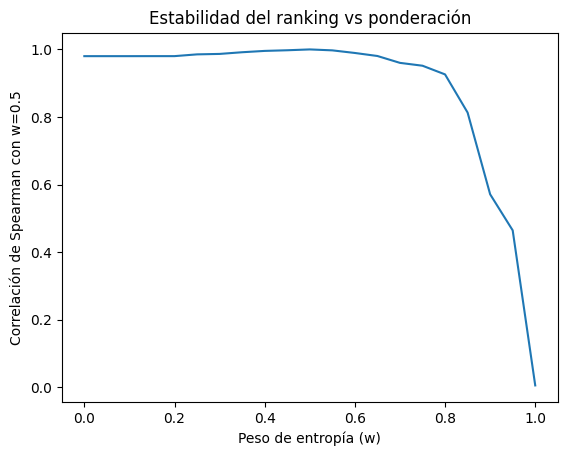

In [74]:
# rango de pesos
ws = np.linspace(0, 1, 21)

correlaciones = []

# índice base (w = 0.5)
df["indice_base"] = 0.5 * df["I_tiempo_norm"] + 0.5 * df["nivel_tiempo"]
rank_base = df["indice_base"].rank()

# calcular correlaciones
for w in ws:
    indice = w * df["I_tiempo_norm"] + (1 - w) * df["nivel_tiempo"]
    rank = indice.rank()
    
    corr, _ = spearmanr(rank_base, rank)
    correlaciones.append(corr)

# gráfico
plt.figure()
plt.plot(ws, correlaciones)
plt.xlabel("Peso de entropía (w)")
plt.ylabel("Correlación de Spearman con w=0.5")
plt.title("Estabilidad del ranking vs ponderación")
plt.show()

Podemos notar estabilidad del ranking en pesos desde 0 hasta aproximadamente 0.7, momento donde comienza a decaer, nos hace indicar que este índice está dominado por la duración del trámite. El colapso al final nos indica que hay trámites raros pero que no necesariamente son largos. Cabe mencionar que se probaron diversidad de indices base con diferencias entre ellos de 1 décima para observar el gráfico y este escenario resulta ser de los más estables sino es el que más. Es de interés observar aquellos trámites que dpeenden de la elección del peso de modo que para distintos índices se modifican sus rankings.

In [75]:
df["cambio"] = df["rank_07"] - df["rank_03"]

df.sort_values("cambio", ascending=False).head(10)

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,Complejidad_tPCA_norm,indice_tiempo,tiempo_0.3,tiempo_0.5,tiempo_0.7,rank_03,rank_05,rank_07,cambio,indice_base
446,8719.0,Aviso de Actualización de Datos para Servicios...,Secretaría de Salud,Secretaría de Salud,Cerrada 115 Cubitos 42090 Pachuca De Soto Pach...,Ambos,0.0,0.0,0.0,Nivel 1,...,0.000000,0.023735,-0.907475,0.023735,0.954945,6.0,212.0,601.0,595.0,0.023735
6,1064.0,Asesoría Jurídica.,Secretaría de Gobierno,Dirección General del Instituto de Defensoría ...,Calle 102 Real de Minas 42090 Pachuca De Soto ...,Ambos,0.0,0.0,0.0,Nivel 1,...,0.000000,0.023735,-0.907475,0.023735,0.954945,6.0,212.0,601.0,595.0,0.023735
341,5805.0,Licitaciones Públicas,Oficialía Mayor,Oficialía Mayor,Calle 901 Jardin Colón 42000 Pachuca De Soto P...,Social,0.0,0.0,0.0,NaN,...,0.000000,0.023735,-0.907475,0.023735,0.954945,6.0,212.0,601.0,595.0,0.023735
234,1133.0,CURP (Clave Única de Registro de Población),Secretaría de Educación Pública,Instituto Hidalguense de Educación,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,2.0,0.0,1.0,Nivel 1,...,0.036981,0.204702,-0.654122,0.204702,1.063525,56.5,220.5,616.5,560.0,0.204702
434,8299.0,Historial académico UTVM,Secretaría de Educación Pública,Universidad Tecnológica del Valle del Mezquital,Carretera S/N El Nith 42300 El Nith Ixmiquilpan,Social,2.0,0.0,1.0,Nivel 4.3,...,0.036981,0.204702,-0.654122,0.204702,1.063525,56.5,220.5,616.5,560.0,0.204702
87,11334.0,"Publicación en el Periódico Oficial, que reali...",Secretaría de Gobierno,Secretaría de Gobierno,Calle 517 Centro 42000 Pachuca De Soto Pachuca...,Ambos,255.0,0.0,0.0,NaN,...,0.394160,0.672992,0.212813,0.672992,1.133171,227.5,397.5,623.5,396.0,0.672992
63,8190.0,Historial Académico UPMH,Secretaría de Educación Pública,Universidad Politécnica Metropolitana de Hidalgo,Boulevard 1009 San Javier 43860 Tolcayuca Tolc...,Social,180.0,0.0,1.0,Nivel 3.7,...,0.382491,0.615886,0.132864,0.615886,1.098907,223.5,393.5,619.5,396.0,0.615886
86,1264.0,"Publicación en el Periódico Oficial, que reali...",Secretaría de Gobierno,Secretaría de Gobierno,Calle 517 Centro 42000 Pachuca De Soto Pachuca...,Ambos,255.0,0.0,0.0,Nivel 1,...,0.394160,0.672992,0.212813,0.672992,1.133171,227.5,397.5,623.5,396.0,0.672992
404,7528.0,Exámenes Generales de Egreso de la Licenciatur...,Secretaría de Educación Pública,Instituto Tecnológico Superior de Huichapan,Calle S/N El Saucillo 42411 Huichapan Huichapan,Social,300.0,0.0,1.0,Nivel 1,...,0.399611,0.699666,0.250156,0.699666,1.149176,230.0,440.0,626.0,396.0,0.699666
487,10587.0,Asesoría Jurídica en Derechos Humanos,Secretaría de Gobierno,Secretaría de Gobierno,Avenida 201 REAL DE MINAS 42090 Pachuca De Sot...,Social,255.0,0.0,0.0,NaN,...,0.394160,0.672992,0.212813,0.672992,1.133171,227.5,397.5,623.5,396.0,0.672992


In [76]:
df.sort_values("cambio").head(10)

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,Complejidad_tPCA_norm,indice_tiempo,tiempo_0.3,tiempo_0.5,tiempo_0.7,rank_03,rank_05,rank_07,cambio,indice_base
634,1612.0,Cancelación de Derecho de Tanto,Secretaría de Infraestructura Pública y Desarr...,Comisión Estatal de Vivienda,Boulevard 117 El Palmar I 42088 Pachuca De Sot...,Social,30.0,1.0,2.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
635,1620.0,Proyecto de Lotificación,Secretaría de Infraestructura Pública y Desarr...,Comisión Estatal de Vivienda,Boulevard 117 El Palmar I 42088 Pachuca De Sot...,Social,30.0,1.0,3.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
630,1527.0,Reinscripción nivel licenciatura UPH,Secretaría de Educación Pública,Universidad Politécnica de Huejutla,Calle s/n tepoxtequito 43000 Huejutla De Reyes...,Social,30.0,1.0,1.0,Nivel 2,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
637,1695.0,Asignación o Cambio de Cromática y Asignación ...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Avenida 205 Colonias 42083 Pachuca De Soto Pac...,Social,30.0,1.0,3.0,Nivel 2,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
638,1701.0,Transferencia por Designación de Persona Benef...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Avenida 205 Colonias 42083 Pachuca De Soto Pac...,Social,30.0,1.0,11.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
40,1260.0,"Publicaciones en el Periódico Oficial, que se ...",Secretaría de Gobierno,Secretaría de Gobierno,Calle 517 Centro 42000 Pachuca De Soto Pachuca...,Ambos,30.0,0.0,0.0,Nivel 1,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
559,1703.0,Extinción de Permisos de Servicio Privado y Co...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Avenida 205 Colonias 42083 Pachuca De Soto Pac...,Social,30.0,1.0,2.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
577,825.0,Pago de Derechos Anuales de las Unidades Autor...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Avenida 205 La Colonia 42083 Pachuca De Soto P...,Social,30.0,1.0,2.0,Nivel 2,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
551,1702.0,Alta Provisional de Albacea de la Concesión de...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Calle 205 Sistema de Transporte Convencional 4...,Social,30.0,1.0,7.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536
589,804.0,Transferencia de Concesión del Servicio de Tra...,Secretaría de Movilidad y Transporte,Sistema de Transporte Convencional de Hidalgo,Avenida 205 Sistema de Transporte Convencional...,Social,30.0,1.0,8.0,NaN,...,0.707808,-0.164536,-0.567913,-0.164536,0.238841,142.0,128.0,88.0,-54.0,-0.164536


A continuación, podemos proponer análisis para la complejidad temporal de cada trámite como identificar trámites con dominancia de duración o de rareza, así como su sensibilidad a las modificaciones del índice propuesto.

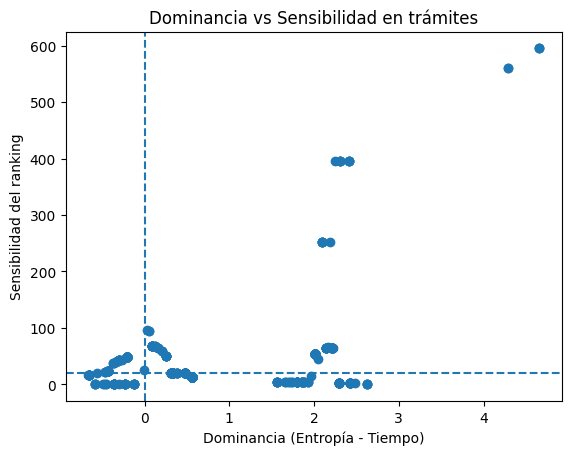

In [77]:
df["dominancia"] = df["I_tiempo_norm"] - df["nivel_tiempo"]
df["sensibilidad"] = (df["rank_07"] - df["rank_03"]).abs()

df["tipo_analisis"] = "default"

df.loc[df["sensibilidad"] > 50, "tipo_analisis"] = "Sensible"
df.loc[df["dominancia"] > 0.2, "tipo_analisis"] = "Dominado por rareza"
df.loc[df["dominancia"] < -0.2, "tipo_analisis"] = "Dominado por tiempo"

# gráfico
plt.figure()
plt.scatter(df["dominancia"], df["sensibilidad"])

# líneas de referencia
plt.axvline(0, linestyle="--")  # equilibrio entre tiempo y entropía
plt.axhline(df["sensibilidad"].median(), linestyle="--")  # umbral de sensibilidad

plt.xlabel("Dominancia (Entropía - Tiempo)")
plt.ylabel("Sensibilidad del ranking")
plt.title("Dominancia vs Sensibilidad en trámites")

plt.show()

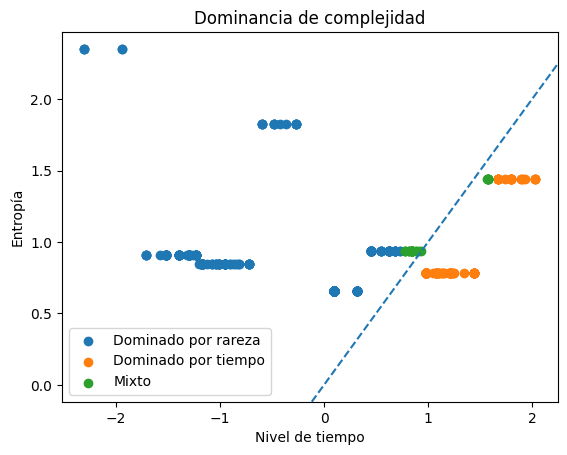

In [78]:
def clasificar_dom(x):
    if x > 0.2:
        return "Dominado por rareza"
    elif x < -0.2:
        return "Dominado por tiempo"
    else:
        return "Mixto"

df["tipo_dominancia"] = df["dominancia"].apply(clasificar_dom)
import matplotlib.pyplot as plt

plt.figure()
for tipo, grupo in df.groupby("tipo_dominancia"):
    plt.scatter(grupo["nivel_tiempo"], grupo["I_tiempo_norm"], label=tipo)

plt.axline((0,0), slope=1, linestyle="--")  # línea de equilibrio
plt.xlabel("Nivel de tiempo")
plt.ylabel("Entropía")
plt.legend()
plt.title("Dominancia de complejidad")
plt.show()

In [79]:
thr_dom = 0.2
thr_sens = df["sensibilidad"].median()

df["tipo_dominancia"] = df["dominancia"].apply(
    lambda x: "Dominado por rareza" if x > thr_dom 
    else ("Dominado por tiempo" if x < -thr_dom 
          else "Mixto")
)

# Conteo por dominancia
df["tipo_dominancia"] = df["dominancia"].apply(
    lambda x: "Rareza" if x > thr_dom else ("Tiempo" if x < -thr_dom else "Mixto")
)

df["tipo_dominancia"].value_counts()

tipo_dominancia
Rareza    480
Tiempo    158
Mixto      27
Name: count, dtype: int64

In [80]:
# Conteo de sensibles
(df["sensibilidad"] > thr_sens).sum()

np.int64(286)

Del mismo modo, ahora construimos la autoinformación de cada trámite para cada una de las variables.

In [81]:
df["I_requisitos"] = self_information(df["requisitos_bin"])
df["I_formatos"] = self_information(df["formatos_bin"])
df["I_digital"] = self_information(df["nivel_digitalizacion_numT"])
df["I_costo"] = self_information(df["costo"])

#Normalizamos
df["I_requisitos_norm"] = df["I_requisitos"] / df["I_requisitos"].max()
df["I_formatos_norm"] = df["I_formatos"] / df["I_formatos"].max()
df["I_digital_norm"] = df["I_digital"] / df["I_digital"].max()
df["I_costo_norm"] = df["I_costo"] / df["I_costo"].max()

df[[
    "I_requisitos_norm",
    "I_formatos_norm",
    "I_digital_norm",
    "I_costo_norm"
]].describe()

,I_requisitos_norm,I_formatos_norm,I_digital_norm,I_costo_norm
count,665.000000,665.000000,665.000000,665.000000
mean,0.298547,0.224076,0.250167,0.508960
std,0.168129,0.159837,0.159560,0.322279
min,0.182939,0.171167,0.143304,0.297760
25%,0.182939,0.171167,0.143304,0.297760
50%,0.282175,0.177745,0.178075,0.297760
75%,0.282175,0.177745,0.346364,1.000000
max,1.000000,1.000000,1.000000,1.000000


Proponemos la construcción del índice de complejidad como el promedio de las contribuciones de las autoinformaciones normalizadas de cada variable junto con el índice temporal.

In [82]:
df["indice_complejidad"] = (
    df["indice_tiempo"] +
    df["I_requisitos_norm"] +
    df["I_formatos_norm"] +
    df["I_digital_norm"] +
    df["I_costo_norm"]
) / 5

O bien, una combinacińn lineal de estas variables utilizando como dato extra la entropía total que habíamos calculado en general para cada variable. Los pesos de cada término serán calculados como el cociente entre la entropía correspondiente entre la entropía total del trámite como la suma de las entropías individuales.

In [83]:
H_total = H_requisitos + H_formatos + H_digital + H_costo + H_tiempo

w_req = H_requisitos / H_total
w_form = H_formatos / H_total
w_dig = H_digital / H_total
w_cost = H_costo / H_total
w_tiempo = H_tiempo / H_total

df["indice_complejidad_w"] = (
    w_req * df["I_requisitos_norm"] +
    w_form * df["I_formatos_norm"] +
    w_dig * df["I_digital_norm"] +
    w_cost * df["I_costo_norm"] +
    w_tiempo * df["indice_tiempo"]
) / 5

Verificamos correlación entre los dos modelos propuestos

In [84]:
np.corrcoef(df["indice_complejidad"], df["indice_complejidad_w"])

array([[1.        , 0.94719812],
       [0.94719812, 1.        ]])

La correlación es alta por lo que los dos enfoques son muy coincidentes entre sí.

In [85]:
w_req, w_form, w_dig, w_cost, w_tiempo

(np.float64(0.19468156926797464),
 np.float64(0.16222028626761742),
 np.float64(0.2584981607968361),
 np.float64(0.09721298092330413),
 np.float64(0.28738700274426765))

Observamos la correlación del índice sin pesos con las variables componentes, así como con las variables originales.

In [86]:
df[["indice_complejidad","I_requisitos_norm", "I_formatos_norm", "I_digital_norm", "I_costo_norm", "indice_tiempo"]].corr()

,indice_complejidad,I_requisitos_norm,I_formatos_norm,I_digital_norm,I_costo_norm,indice_tiempo
indice_complejidad,1.000000,0.211215,0.322501,0.239578,0.455960,0.780615
I_requisitos_norm,0.211215,1.000000,0.256401,0.071882,-0.184612,-0.036773
I_formatos_norm,0.322501,0.256401,1.000000,0.052159,0.017616,0.000330
I_digital_norm,0.239578,0.071882,0.052159,1.000000,-0.078333,0.012753
I_costo_norm,0.455960,-0.184612,0.017616,-0.078333,1.000000,0.049457
indice_tiempo,0.780615,-0.036773,0.000330,0.012753,0.049457,1.000000


In [87]:
df[["indice_complejidad","CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_complejidad,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_complejidad,1.000000,0.175710,0.265007,0.189333,-0.455960,0.495719
CONTEO_NETO,0.175710,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.265007,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,0.189333,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,-0.455960,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.495719,0.041961,-0.027326,-0.028423,-0.056578,1.000000


Identificamos que su relación con el costo es negativa y muy alta en ambos enfoques, variable normal y entropia. Lo que podemos inferir de este análisis es que, si la distribución de los trámites que tienen un costo comparado con los que no es muy evidente, podemos suponer que la entropía está siendo malinterpretada ya que el hecho de que la correlación del índice con la variable costo sea negativa podría indicarnos que si un trámite cuesta entonces es menos complicado, contraintuitivo.

In [88]:
df["indice_complejidad"].describe()

count    665.000000
mean       0.343285
std        0.134644
min        0.078267
25%        0.240762
50%        0.355761
75%        0.413769
max        0.843153
Name: indice_complejidad, dtype: float64

In [89]:
df["costo"].value_counts(normalize=True)

costo
1.0    0.699248
0.0    0.300752
Name: proportion, dtype: float64

Aproximadamente el 70% de los trámites sí cuestan. Proponemos realizar un índice sin considerar el costo para observar qué tan relevante es el dato y utilizamos los dos índices para calcular la correlación con una variable externa y verificar si la correlación entre variables empeora si se omite el costo.

In [90]:
df["indice_sin_costo"] = (
    df["I_requisitos_norm"] +
    df["I_formatos_norm"] +
    df["I_digital_norm"] +
    df["indice_tiempo"]
) / 4

np.corrcoef(df["indice_complejidad"], df["Tiempo_en_minutos"])

array([[1.        , 0.49571919],
       [0.49571919, 1.        ]])

In [91]:
np.corrcoef(df["indice_sin_costo"], df["Tiempo_en_minutos"])

array([[1.        , 0.52638367],
       [0.52638367, 1.        ]])

La correlación con la variable externa de tiempo aumentó muy poco, por lo que decimos que el costo es una parte que sí aporta información al índice y no es sugerible omitirlo. Otra prueba para llegar a esta misma sugerencia es observar los rankings de los trámites con uno u otro índice, si éstos cambian mucho entonces el modelo sin costo sí modifica todo el análisis.

In [92]:
df["rank_con"] = df["indice_complejidad"].rank()
df["rank_sin"] = df["indice_sin_costo"].rank()

df["cambio"] = df["rank_sin"] - df["rank_con"]
df["cambio"].abs().mean()

np.float64(87.28571428571429)

Tiene valores muy altos. Finalmente, si observamos la dispersión de los datos de cada índice:

In [93]:
df["indice_complejidad"].std()

np.float64(0.1346442885602398)

In [94]:
df["indice_sin_costo"].std()

np.float64(0.14984071397668083)

La dispersión en el índice sin costo es mayor, por lo que estos tres análisis nos pueden indicar la mejoría del modelo con el costo.

In [95]:
df[["indice_sin_costo","CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "Tiempo_en_minutos"]].corr()

,indice_sin_costo,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,Tiempo_en_minutos
indice_sin_costo,1.000000,0.318693,0.318623,0.297319,0.526384
CONTEO_NETO,0.318693,1.000000,0.360923,0.091979,0.041961
N_FORMATOS_FINAL,0.318623,0.360923,1.000000,-0.019608,-0.027326
nivel_digitalizacion_numT,0.297319,0.091979,-0.019608,1.000000,-0.028423
Tiempo_en_minutos,0.526384,0.041961,-0.027326,-0.028423,1.000000


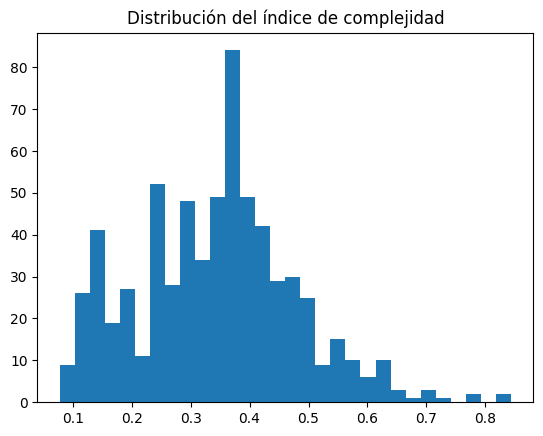

In [96]:
plt.hist(df["indice_complejidad"], bins=30)
plt.title("Distribución del índice de complejidad")

plt.show()

El costo sí aporta información al índice pero no es la mejor opción utilizar entropía para describirlo, ya que la entropía nos ofrece ver la rareza de encontrar cierto valor, en este caso, al tener costo solo dos valores, el valor más raro es el de no costo (0) de modo que la entropía será alta por tener distribuciones distintas del valor (70% son 1 y 30% son 0) entonces se notificará e interpretará mal como que aumenta de complejo conforme los trámites son gratuitos, lo que es poco intuitivo. Se opta por utilizar la variable directamente como aporte de fricción al modelo.

In [97]:
df["indice_complejidad_costo"] = (
     df["I_requisitos_norm"] +
     df["I_formatos_norm"] +
     df["I_digital_norm"] +
     df["costo"] +
     df["indice_tiempo"]
)

df[["indice_complejidad_costo", "I_requisitos_norm", "I_formatos_norm", "I_digital_norm", "I_costo_norm", "indice_tiempo"]].corr()

,indice_complejidad_costo,I_requisitos_norm,I_formatos_norm,I_digital_norm,I_costo_norm,indice_tiempo
indice_complejidad_costo,1.000000,0.374820,0.266119,0.291154,-0.620628,0.637174
I_requisitos_norm,0.374820,1.000000,0.256401,0.071882,-0.184612,-0.036773
I_formatos_norm,0.266119,0.256401,1.000000,0.052159,0.017616,0.000330
I_digital_norm,0.291154,0.071882,0.052159,1.000000,-0.078333,0.012753
I_costo_norm,-0.620628,-0.184612,0.017616,-0.078333,1.000000,0.049457
indice_tiempo,0.637174,-0.036773,0.000330,0.012753,0.049457,1.000000


In [98]:
df[["indice_complejidad_costo", "CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_complejidad_costo,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_complejidad_costo,1.000000,0.385490,0.273327,0.327759,0.620628,0.378895
CONTEO_NETO,0.385490,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.273327,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,0.327759,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,0.620628,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.378895,0.041961,-0.027326,-0.028423,-0.056578,1.000000


En este nuevo enfoque directo del costo podemos ver que se le asigna correspondencia positiva al índice. La interpretación del costo es correcta con lo que nos refiere al índice. 
Otra observación similar es el nivel de digitalización, dado que entropía muestra rareza en los datos, para el nivel de digitalización sabemos que ya se tiene asignado uno específicamente; si dejamos el enfoque de entropía en este caso, entre más alto sea el nivel digital, mayor será el índice de complejidad, lo que es contraintuitivo también pues una alta digitalización debería reducir la complejidad. Proponemos que, al igual que costo, se utilice esta variable directamente reescalada a un rango de 0 a 1 y escogiendo que, entre más bajo sea más alto el valor.

In [99]:
df["digital_norm"] = 1 - (df["nivel_digitalizacion_numT"] / df["nivel_digitalizacion_numT"].max())

df["indice_complejidad_ajuste"] = (
     df["I_requisitos_norm"] +
     df["I_formatos_norm"] +
     df["digital_norm"] +
     df["costo"] +
     df["indice_tiempo"]
)

df[["indice_complejidad_ajuste", "I_requisitos_norm", "I_formatos_norm", "I_digital_norm", "I_costo_norm", "indice_tiempo"]].corr()

,indice_complejidad_ajuste,I_requisitos_norm,I_formatos_norm,I_digital_norm,I_costo_norm,indice_tiempo
indice_complejidad_ajuste,1.000000,0.349722,0.255382,-0.200542,-0.574679,0.642858
I_requisitos_norm,0.349722,1.000000,0.256401,0.071882,-0.184612,-0.036773
I_formatos_norm,0.255382,0.256401,1.000000,0.052159,0.017616,0.000330
I_digital_norm,-0.200542,0.071882,0.052159,1.000000,-0.078333,0.012753
I_costo_norm,-0.574679,-0.184612,0.017616,-0.078333,1.000000,0.049457
indice_tiempo,0.642858,-0.036773,0.000330,0.012753,0.049457,1.000000


In [100]:
df[["indice_complejidad_ajuste", "CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_complejidad_ajuste,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_complejidad_ajuste,1.000000,0.350645,0.282387,-0.177807,0.574679,0.408663
CONTEO_NETO,0.350645,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.282387,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,-0.177807,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,0.574679,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.408663,0.041961,-0.027326,-0.028423,-0.056578,1.000000


De este modo podemos distinguir la correspondencia intuitiva de estas variables finalmente, sin embargo, la correlación con el costo sigue siendo muy alta. Proponemos ajustar el índice con pesos definidos por componentes principales (PCA).

In [101]:
X = df[[
    "indice_tiempo",
    "I_requisitos_norm",
    "I_formatos_norm",
    "digital_norm",
    "costo"
]].dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
complejidad = pca.fit_transform(X_scaled)

df.loc[X.index, "Complejidad_F1PCA"] = complejidad
print("--------------------------")
print(pca.components_)

print(pca.explained_variance_ratio_)
print("--------------------------")

df["Complejidad_F1PCA_norm"] = (
    (df["Complejidad_F1PCA"] - df["Complejidad_F1PCA"].min()) /
    (df["Complejidad_F1PCA"].max() - df["Complejidad_F1PCA"].min())
)

#df[["Complejidad_tPCA_norm", "nivel_tiempo", "I_tiempo"]].sort_values("Complejidad_tPCA_norm")



--------------------------
[[-0.08490014  0.64957642  0.46419177 -0.3591046   0.47582805]]
[0.2724956]
--------------------------


Este análisis le quita casi por completo el peso del tiempo, descartamos esta opción.

In [102]:
df[[
    "I_requisitos_norm",
    "I_formatos_norm",
    "digital_norm",
    "costo",
    "indice_tiempo"
]].std()

I_requisitos_norm    0.168129
I_formatos_norm      0.159837
digital_norm         0.243288
costo                0.458930
indice_tiempo        0.513683
dtype: float64

La variabilidad de los datos sigue confirmando que costo está dominando en el índice. Para mejorar el índice entonces proponemos estandarizar las variables que lo componen, un z-score, ya que el costo es una variable que es más dispersa de modo que si se deja ese índice le dará más peso a aquella variable que varíe más.

In [103]:
for col in [
    "I_requisitos_norm",
    "I_formatos_norm",
    "indice_tiempo",
    "digital_norm",
    "costo"
]:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

In [104]:
df["indice_z"] = (
    df["I_requisitos_norm_z"] +
    df["I_formatos_norm_z"] +
    df["indice_tiempo_z"] +
    df["digital_norm_z"] +
    df["costo_z"]
) / 5

df[["indice_z", "I_requisitos_norm_z", "I_formatos_norm_z", "digital_norm_z", "costo_z", "indice_tiempo_z"]].corr()

,indice_z,I_requisitos_norm_z,I_formatos_norm_z,digital_norm_z,costo_z,indice_tiempo_z
indice_z,1.000000,0.592139,0.537795,0.309783,0.426394,0.385567
I_requisitos_norm_z,0.592139,1.000000,0.256401,-0.070932,0.184612,-0.036773
I_formatos_norm_z,0.537795,0.256401,1.000000,-0.028174,-0.017616,0.000330
digital_norm_z,0.309783,-0.070932,-0.028174,1.000000,-0.157436,-0.045926
costo_z,0.426394,0.184612,-0.017616,-0.157436,1.000000,-0.049457
indice_tiempo_z,0.385567,-0.036773,0.000330,-0.045926,-0.049457,1.000000


In [105]:
df[["indice_z", "CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_z,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_z,1.000000,0.577846,0.532689,-0.309783,0.426394,0.275598
CONTEO_NETO,0.577846,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.532689,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,-0.309783,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,0.426394,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.275598,0.041961,-0.027326,-0.028423,-0.056578,1.000000


In [106]:
df[[
    "indice_z",
    "I_requisitos_norm_z",
    "I_formatos_norm_z",
    "indice_tiempo_z",
    "digital_norm_z",
    "costo_z"
]].corr()["indice_z"]

indice_z               1.000000
I_requisitos_norm_z    0.592139
I_formatos_norm_z      0.537795
indice_tiempo_z        0.385567
digital_norm_z         0.309783
costo_z                0.426394
Name: indice_z, dtype: float64

In [107]:
df_top = df.sort_values("indice_z", ascending=False).head(10)
df_top

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,digital_norm,indice_complejidad_ajuste,Complejidad_F1PCA,Complejidad_F1PCA_norm,I_requisitos_norm_z,I_formatos_norm_z,indice_tiempo_z,digital_norm_z,costo_z,indice_z
573,1476.0,Autorización para Prestar Servicios de Segurid...,Secretaría de Seguridad Pública,Secretaría de Seguridad Pública,Boulevard S/N Fraccionamiento Colosio II 42039...,Ambos,14400.0,12.0,11.0,Nivel 1,...,0.928571,4.821548,5.075618,0.992176,4.172102,4.854479,0.892192,0.355848,0.655333,2.185991
147,6717.0,Convocatoria del Instituto de Formación Profes...,Secretaría de Seguridad Pública,Secretaría de Seguridad Pública,Carretera Km. 0+500 San José Palma Gorda 42188...,Social,64800.0,3.0,15.0,Nivel 1,...,0.928571,3.873674,3.665823,0.787437,4.172102,4.113973,1.224080,0.355848,-1.523648,1.668471
281,1506.0,Expedición de Tarjetón para Personas Conductor...,Secretaría de Movilidad y Transporte,Sistema de Transporte Masivo de Hidalgo,"Calle Km 1 Blvd. Camino a Téllez Km. 1, Jagüey...",Social,1440.0,2.0,13.0,Nivel 1,...,0.928571,3.893832,3.973920,0.832181,4.172102,2.298066,-0.118369,0.355848,0.655333,1.472596
649,8907.0,Constancia de terminación de estadía UPP,Secretaría de Educación Pública,Universidad Politécnica de Pachuca,Carretera S/N Santa Bárbara 43830 Zempoala Zem...,Social,4320.0,3.0,11.0,Nivel 2,...,0.857143,3.433465,3.832331,0.811618,4.172102,4.113973,0.506166,0.062251,-1.523648,1.466169
236,1135.0,Registro Profesional Estatal,Secretaría de Educación Pública,Secretaría de Educación Pública,Circuito Lote 17 Ex Hacienda La Concepción 421...,Social,60.0,5.0,7.0,Nivel 2,...,0.857143,3.501881,4.169064,0.860521,2.374533,4.854479,-0.949438,0.062251,0.655333,1.399432
2,9229.0,Canje de Placas,Secretaría de Hacienda,Secretaría de Hacienda,Calle 801 Canutillo 42060 Pachuca De Soto Pach...,Ambos,20.0,3.0,10.0,NaN,...,1.000000,3.381939,3.637936,0.783387,2.374533,4.113973,-1.230621,0.649445,0.655333,1.312532
4,10885.0,Cambio de Propietario,Secretaría de Hacienda,Secretaría de Hacienda,Calle 1 Centro 42500 Actopan Actopan,Ambos,1440.0,2.0,7.0,NaN,...,1.000000,3.663036,2.699871,0.647155,2.374533,2.298066,-0.118369,0.649445,0.655333,1.171802
29,694.0,Autorregulación Ambiental,Secretaría de Medio Ambiente y Recursos Naturales,Secretaría de Medio Ambiente y Recursos Naturales,Calle 100 Adolfo López Mateos 42094 Pachuca De...,Social,36000.0,2.0,4.0,NaN,...,1.000000,4.037615,1.758182,0.510397,1.076751,2.298066,1.035599,0.649445,0.655333,1.143039
293,1557.0,Autorización para impartir educación inicial y...,Secretaría de Educación Pública,Instituto Hidalguense de Educación,Boulevard S/N Venta Prieta 42083 Pachuca De So...,Social,18720.0,3.0,2.0,Nivel 2,...,0.857143,3.957150,2.054546,0.553437,-0.097376,4.113973,0.976319,0.062251,0.655333,1.142100
106,1541.0,Refrendo anual de registro de perito valuador,Secretaría de Hacienda,Instituto Catastral,Calle 105 Real de Minas 42090 Pachuca De Soto ...,NaN,172800.0,2.0,2.0,NaN,...,1.000000,4.430098,0.897355,0.385382,-0.097376,2.298066,2.183949,0.649445,0.655333,1.137883


In [108]:
df.sort_values("indice_z").head(10)

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,digital_norm,indice_complejidad_ajuste,Complejidad_F1PCA,Complejidad_F1PCA_norm,I_requisitos_norm_z,I_formatos_norm_z,indice_tiempo_z,digital_norm_z,costo_z,indice_z
426,8154.0,Becas UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,8.0,1.0,1.0,Nivel 4.1,...,0.142857,0.166495,-0.146807,0.233742,-0.687617,-0.289869,-1.502325,-2.873716,-1.523648,-1.375435
434,8299.0,Historial académico UTVM,Secretaría de Educación Pública,Universidad Tecnológica del Valle del Mezquital,Carretera S/N El Nith 42300 El Nith Ixmiquilpan,Social,2.0,0.0,1.0,Nivel 4.3,...,0.000000,0.558808,-0.044507,0.248599,-0.687617,-0.331019,-0.447691,-3.460909,-1.523648,-1.290177
31,6938.0,Historial académico UTT,Secretaría de Educación Pública,Universidad Tecnológica de Tulancingo,Calle 301 Las Presas 43642 Tulancingo De Bravo...,Social,1440.0,0.0,0.0,Nivel 4.2,...,0.071429,0.799403,-0.177998,0.229212,-0.687617,-0.331019,-0.118369,-3.167312,-1.523648,-1.165593
26,6935.0,Credencial Institucional UTT,Secretaría de Educación Pública,Universidad Tecnológica de Tulancingo,Calle 301 Las Presas 43642 Tulancingo De Bravo...,Social,1440.0,0.0,0.0,Nivel 4.2,...,0.071429,0.799403,-0.177998,0.229212,-0.687617,-0.331019,-0.118369,-3.167312,-1.523648,-1.165593
239,1142.0,Registro como unidad receptora de servicio social,Secretaría de Educación Pública,Secretaría de Educación Pública,Circuito Lote 17 Ex Hacienda La Concepción 421...,Ambos,1440.0,1.0,2.0,Nivel 4.1,...,0.142857,0.976646,0.119301,0.272388,-0.097376,-0.289869,-0.118369,-2.873716,-1.523648,-0.980595
392,7446.0,Examen Toefl UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,0.142857,1.299487,0.848592,0.378300,-0.687617,-0.331019,-1.230621,-2.873716,0.655333,-0.893528
394,7448.0,Examen Extraordinario UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,0.142857,1.299487,0.848592,0.378300,-0.687617,-0.331019,-1.230621,-2.873716,0.655333,-0.893528
393,7447.0,Examen de Competencia Profesional UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,0.142857,1.299487,0.848592,0.378300,-0.687617,-0.331019,-1.230621,-2.873716,0.655333,-0.893528
387,7434.0,Examen de Egreso de Licenciatura UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,0.142857,1.299487,0.848592,0.378300,-0.687617,-0.331019,-1.230621,-2.873716,0.655333,-0.893528
296,1560.0,Preinscripciones de Educación Básica,Secretaría de Educación Pública,Instituto Hidalguense de Educación,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,47520.0,0.0,1.0,Nivel 4.1,...,0.142857,1.509337,-0.389120,0.198552,-0.687617,-0.331019,1.124625,-2.873716,-1.523648,-0.858275


Como requisitos y formatos tienen el mismo comportamiento, podemos incluso proponer una variable como la suma de estas dos para observar diferencias con el modelo.

In [109]:
df["suma_N"]=df["I_formatos_norm"]+df["I_requisitos_norm"]

df["suma_N_z"] = (df["suma_N"] - df["suma_N"].mean()) / df["suma_N"].std()

df["indice_z2"] = (
    df["suma_N_z"] +
    df["indice_tiempo_z"] +
    df["digital_norm_z"] +
    df["costo_z"]
) / 4

df[["indice_z2", "suma_N_z", "digital_norm_z", "costo_z", "indice_tiempo_z"]].corr()

,indice_z2,suma_N_z,digital_norm_z,costo_z,indice_tiempo_z
indice_z2,1.000000,0.543231,0.389937,0.479367,0.468404
suma_N_z,0.543231,1.000000,-0.063191,0.108553,-0.023578
digital_norm_z,0.389937,-0.063191,1.000000,-0.157436,-0.045926
costo_z,0.479367,0.108553,-0.157436,1.000000,-0.049457
indice_tiempo_z,0.468404,-0.023578,-0.045926,-0.049457,1.000000


In [110]:
df[["indice_z2", "CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_z2,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_z2,1.000000,0.458906,0.410309,-0.389937,0.479367,0.322913
CONTEO_NETO,0.458906,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.410309,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,-0.389937,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,0.479367,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.322913,0.041961,-0.027326,-0.028423,-0.056578,1.000000


In [111]:
np.corrcoef(df["indice_z"], df["indice_z2"])

array([[1.       , 0.9757288],
       [0.9757288, 1.       ]])

In [112]:
df["rank_z"] = df["indice_z"].rank()
df["rank_z2"] = df["indice_z2"].rank()

df["cambio"] = df["rank_z2"] - df["rank_z"]

df["cambio"].describe()

count    665.000000
mean       0.000000
std       33.180004
min     -244.000000
25%       -7.000000
50%        7.000000
75%       19.000000
max       56.000000
Name: cambio, dtype: float64

La correlación entre ambas es muy parecida pero en los rankings los trámites cambian mucho de posición. Por ahora, conservaremos el modelo original.
El paso siguiente corresponde al análisis gráfico de las interpretaciones que el modelo arroja.

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Análisis del modelo
</h4>

Utilizando el índice con las 5 variables, desarrollamos el gráfico complejidad vs duración donde distinguimos que el tiempo no es el factor con mayor pero en el índice pues hay trámites muy largos no necesariamente complejos mientras que hay trámites cortos muy complejos.

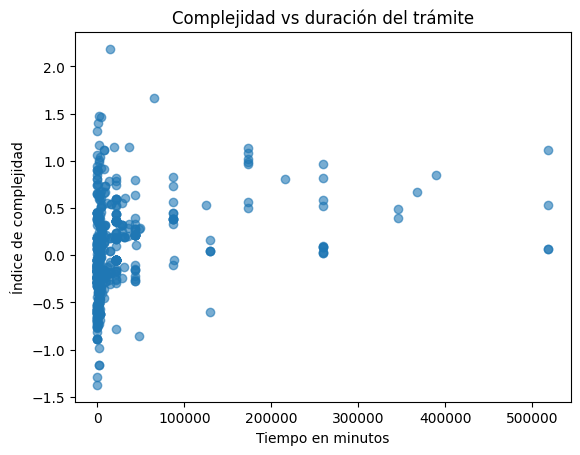

In [113]:
plt.scatter(df["Tiempo_en_minutos"], df["indice_z"], alpha=0.6)
plt.xlabel("Tiempo en minutos")
plt.ylabel("Índice de complejidad")
plt.title("Complejidad vs duración del trámite")
plt.show()

También, podemos visualizar la distribución del indice a través de los trámites con un histograma que existe entre el valor mínimo y máximo del índice. Notamos una mayor distribución entre -0.5 y +0.5. Cabe recalcar que estos valores se pueden reescalar a puramente positivos.

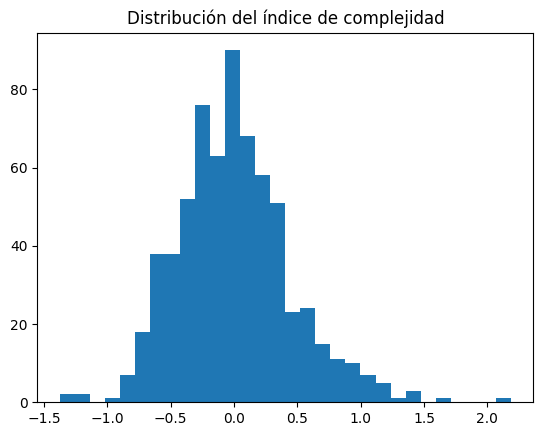

In [114]:
plt.hist(df["indice_z"], bins=30)
plt.title("Distribución del índice de complejidad")
plt.show()

En los siguientes dos gráficos es posible también ver el aporte promedio y general que hace cada una de las dimensiones al índice, distinguiendo mayor aporte por parte de costo y tiempo.

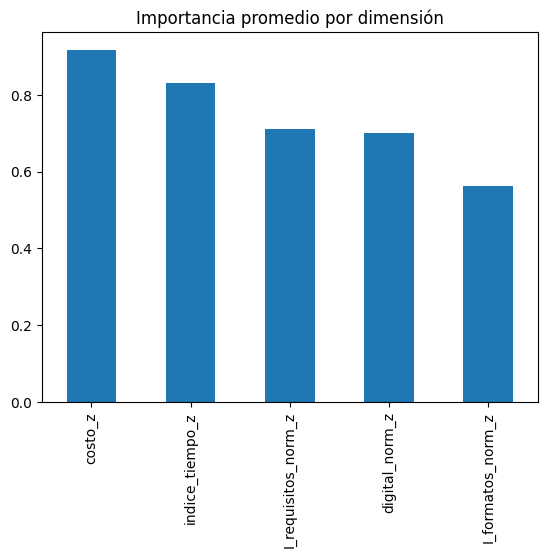

In [115]:
cols = [
    "I_requisitos_norm_z",
    "I_formatos_norm_z",
    "indice_tiempo_z",
    "digital_norm_z",
    "costo_z"
]

df[cols].abs().mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Importancia promedio por dimensión")
plt.show()

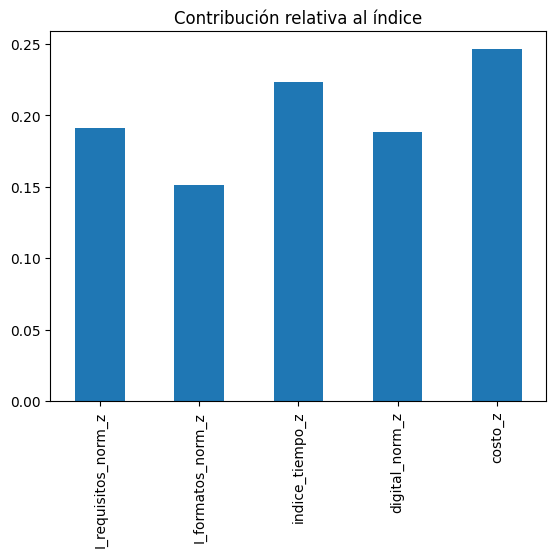

In [116]:
contrib = df[cols].abs().mean()
contrib = contrib / contrib.sum()

contrib.plot(kind="bar")
plt.title("Contribución relativa al índice")
plt.show()

Además, cada una de las dimensiones tiene cierto comportamiento que podemos observar en los sigueintes boxplots, distinguiendo algunos outliers en la dimensión de variación de formatos y requisitos, así como de la digitalización, este último tiene sesgo positivo. También observamos propia estabilidad en el tiempo y en costo.

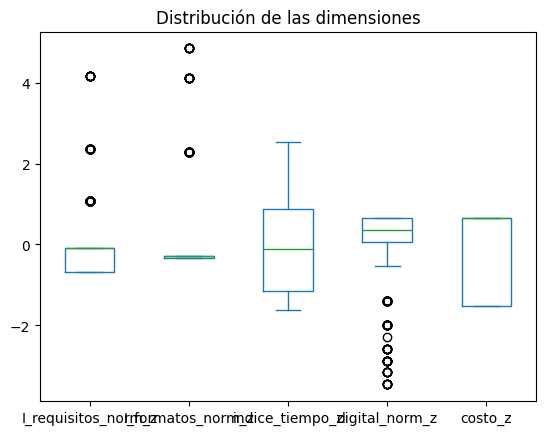

In [117]:
df[[
    "I_requisitos_norm_z",
    "I_formatos_norm_z",
    "indice_tiempo_z",
    "digital_norm_z",
    "costo_z"
]].plot(kind="box")
plt.title("Distribución de las dimensiones")
plt.show()

En el siguiente gráfico podemos distinguir la comparación promedio del aporte de las dimensiones del índice en los top 10 más y menos complejos. Este gráfico sirve para observar que requisitos y formatos son un gran indicador de complejidad pues en los top 10 más complejos tienen, en promedio, grandes niveles. Asimismo, se muestra que para trámites más fáciles la digitalización es clave. Sobre el tiempo y el costo, presentan indicadores medios que varian moderadamente entre los datos.

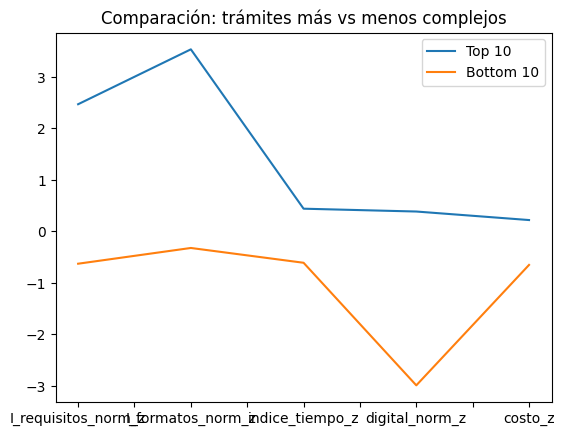

In [118]:
top = df.sort_values("indice_z", ascending=False).head(10)
bottom = df.sort_values("indice_z").head(10)

top[cols].mean().plot(label="Top 10")
bottom[cols].mean().plot(label="Bottom 10")

plt.legend()
plt.title("Comparación: trámites más vs menos complejos")
plt.show()

Podemos mostrar directa y gráficamente la correlación entre las variables originales de los trámites con el indice propuesto. Observamos dominancia en requisitos y formatos.

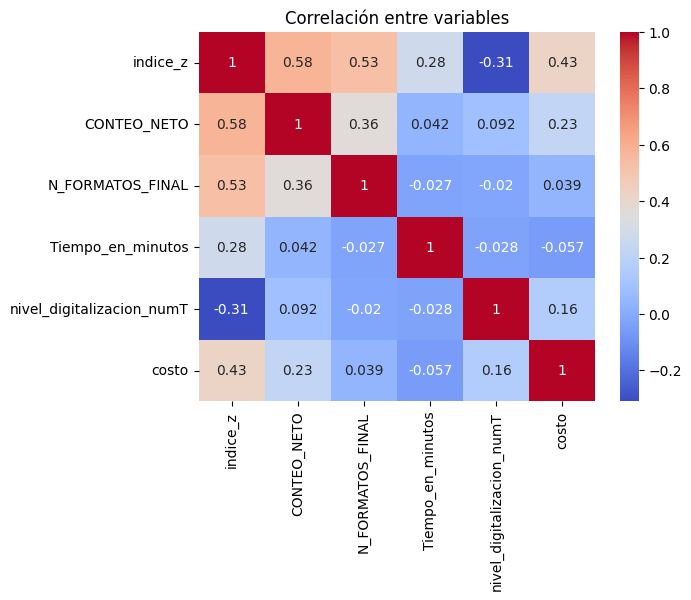

In [119]:
import seaborn as sns

sns.heatmap(df[[
    "indice_z",
    "CONTEO_NETO",
    "N_FORMATOS_FINAL",
    "Tiempo_en_minutos",
    "nivel_digitalizacion_numT",
    "costo"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlación entre variables")
plt.show()

De forma gráfica, observamos las distribuciones del índice de complejidad a través de los rankings donde la posición 1 sería el menos complejo y el 665 el más complejo.

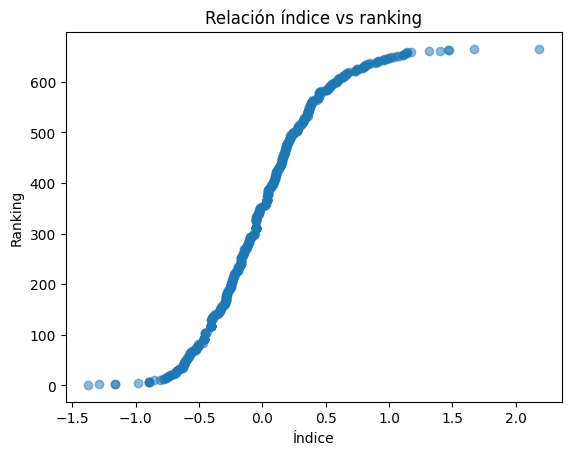

In [120]:
plt.scatter(df["indice_z"], df["rank_z"], alpha=0.5)
plt.xlabel("Índice")
plt.ylabel("Ranking")
plt.title("Relación índice vs ranking")
plt.show()

El siguiente gráfico de comparación entre la componente de complejidad temporal con la componente de complejidad documental (formatos + requisitos) permite ver relaciones como que los de mayor tiempo no tienen demasiados requisitos y viceversa.

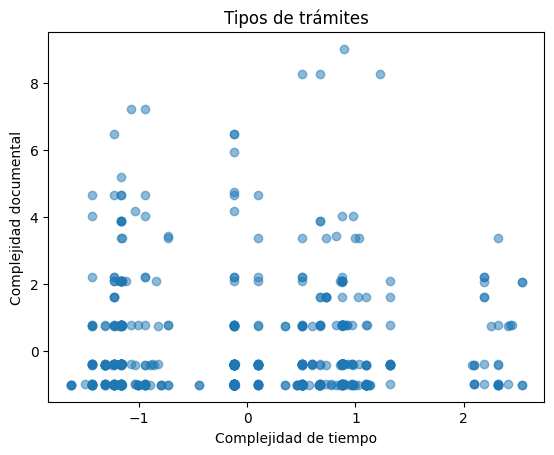

In [121]:
plt.scatter(
    df["indice_tiempo_z"],
    df["I_requisitos_norm_z"] + df["I_formatos_norm_z"],
    alpha=0.5
)

plt.xlabel("Complejidad de tiempo")
plt.ylabel("Complejidad documental")
plt.title("Tipos de trámites")
plt.show()


Ahora, utilizando las componentes del indice propuesto desarrollamos un análisis de K-means que permita agrupar los datos en k grupos. La determinación de los grupos la obtendremos a través del método del codo, un gráfico de prueba de k's donde, las relaciones lineales entre valores de distintos k's decaen drásticamente hasta encontrarse con un k codo que frene el gran decaimiento. Ese k específico es el que escogeremos para la agrupación.

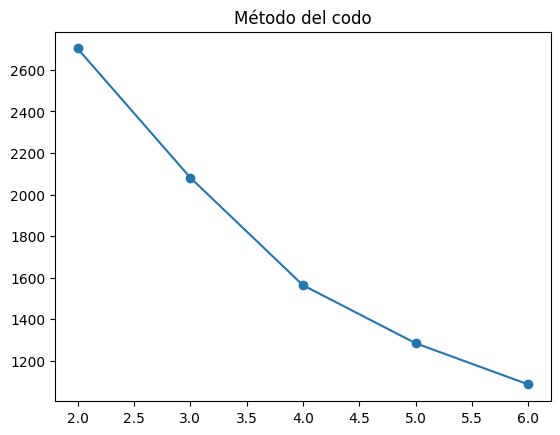

In [122]:
inertia = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[cols])
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia, marker='o')
plt.title("Método del codo")
plt.show()

Una vez determinado un valor de k=4 procedemos con la agrupación.

In [123]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(df[cols])

df.groupby("cluster")[cols].mean()

,I_requisitos_norm_z,I_formatos_norm_z,indice_tiempo_z,digital_norm_z,costo_z
cluster,,,,,
0,0.031721,-0.283852,0.263773,-2.150541,0.471839
1,0.047612,-0.309023,-0.123829,0.421092,0.655333
2,-0.361913,-0.313755,0.067450,0.386220,-1.523648
3,0.700072,2.927999,0.070483,-0.049595,0.032767


Podemos interpretar el cluster 0 como trámites altamente digitalizados y algo lentos (con costo), el cluster 1 para trámites estándar con costo, el cluster 2 para trámites simples y gratuitos, y el cluster 3 para trámites altamente burocráticos.

In [124]:
df["cluster"].value_counts()

cluster
1    333
2    174
0     95
3     63
Name: count, dtype: int64

In [125]:
df.groupby("cluster")["indice_z"].mean()

cluster
0   -0.333412
1    0.138237
2   -0.349129
3    0.736345
Name: indice_z, dtype: float64

Utilizando el mismo gráfico de compleidad documental vs complejidad temporal, podemos observar una separación específica del color 1, básicamente representando al cluster 3 que determina burocracia en los trámites.

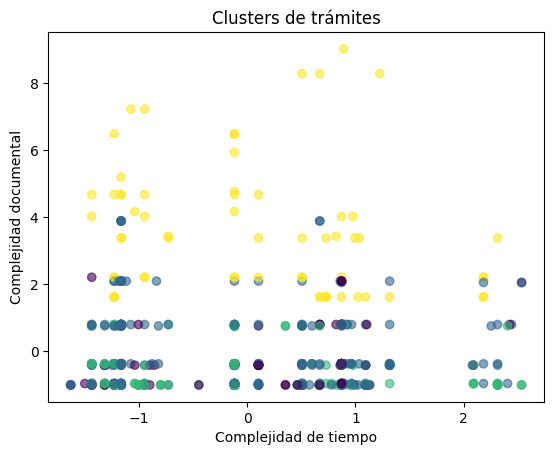

In [126]:
plt.scatter(
    df["indice_tiempo_z"],
    df["I_requisitos_norm_z"] + df["I_formatos_norm_z"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Complejidad de tiempo")
plt.ylabel("Complejidad documental")
plt.title("Clusters de trámites")
plt.show()

Podemos incluso separar dependencias por designación porcentual de cluster 

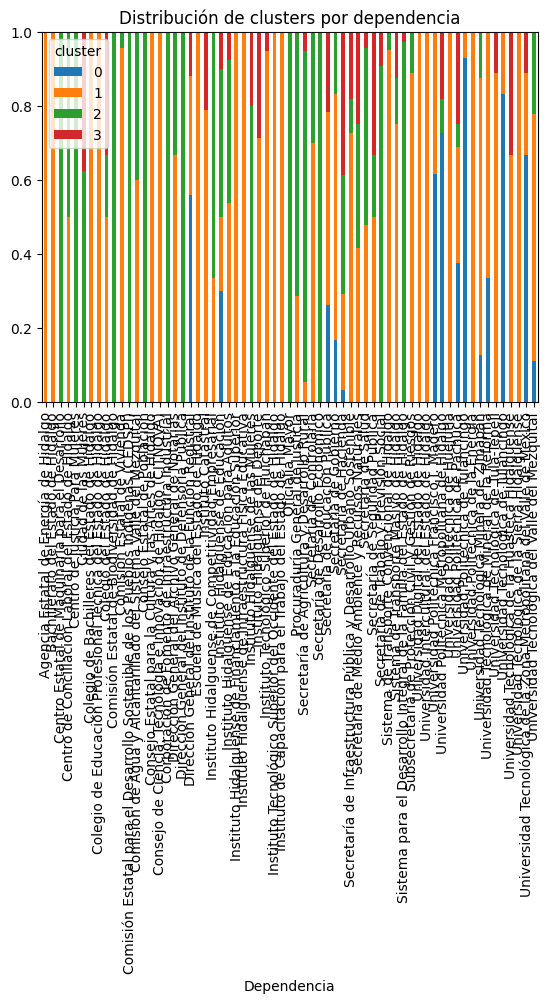

In [127]:
tabla = pd.crosstab(df["Dependencia"], df["cluster"])
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)
tabla_prop.plot(kind="bar", stacked=True)
plt.title("Distribución de clusters por dependencia")
plt.show()

In [128]:
tabla_prop

cluster,0,1,2,3
Dependencia,,,,
Agencia Estatal de Energía de Hidalgo,0.000000,1.000000,0.000000,0.000000
Bachillerato del Estado de Hidalgo,0.000000,1.000000,0.000000,0.000000
Centro Estatal de Maquinaria para el Desarrollo,0.000000,0.000000,1.000000,0.000000
Centro de Conciliación Laboral del Estado de Hidalgo,0.000000,0.500000,0.500000,0.000000
Centro de Justicia Para Mujeres,0.000000,0.000000,1.000000,0.000000
...,...,...,...,...
Universidad Tecnológica de Tulancingo,0.833333,0.166667,0.000000,0.000000
Universidad Tecnológica de la Huasteca Hidalguense,0.000000,0.666667,0.000000,0.333333
Universidad Tecnológica de la Sierra Hidalguense,0.000000,1.000000,0.000000,0.000000


In [129]:
df.to_csv("tramites_procesados.csv", index=False)

Asimismo, analizar las dependencias con mayor indice de complejidad promedio.

In [130]:
resumen = df.groupby("Dependencia")["indice_z"].agg(["mean", "count"])
resumen = resumen.sort_values("mean", ascending=False)

resumen

,mean,count
Dependencia,,
Secretaría de Seguridad Pública,0.575011,6
Instituto Catastral,0.474526,19
Secretaría de Educación Pública,0.388373,23
Instituto Hidalguense de Financiamiento a la Educación Superior,0.380371,1
Secretaría de Medio Ambiente y Recursos Naturales,0.347952,12
...,...,...
Dirección General del Instituto de Defensoría Pública,-0.529122,2
Centro de Justicia Para Mujeres,-0.583346,6
Secretaría de Desarrollo Económico,-0.636410,6


In [131]:
resumen_filtrado = resumen[resumen["count"] >= 10]
resumen_filtrado.sort_values("mean", ascending=False)

,mean,count
Dependencia,,
Instituto Catastral,0.474526,19
Secretaría de Educación Pública,0.388373,23
Secretaría de Medio Ambiente y Recursos Naturales,0.347952,12
Instituto Tecnológico Superior del Occidente del Estado de Hidalgo,0.285291,12
Secretaría de Infraestructura Pública y Desarrollo Urbano Sostenible,0.200989,22
Dirección General del Instituto de la Función Registral,0.195930,59
Instituto Tecnológico Superior de Huichapan,0.191499,19
Sistema de Transporte Convencional de Hidalgo,0.162978,21
Secretaría de Hacienda,0.128862,31


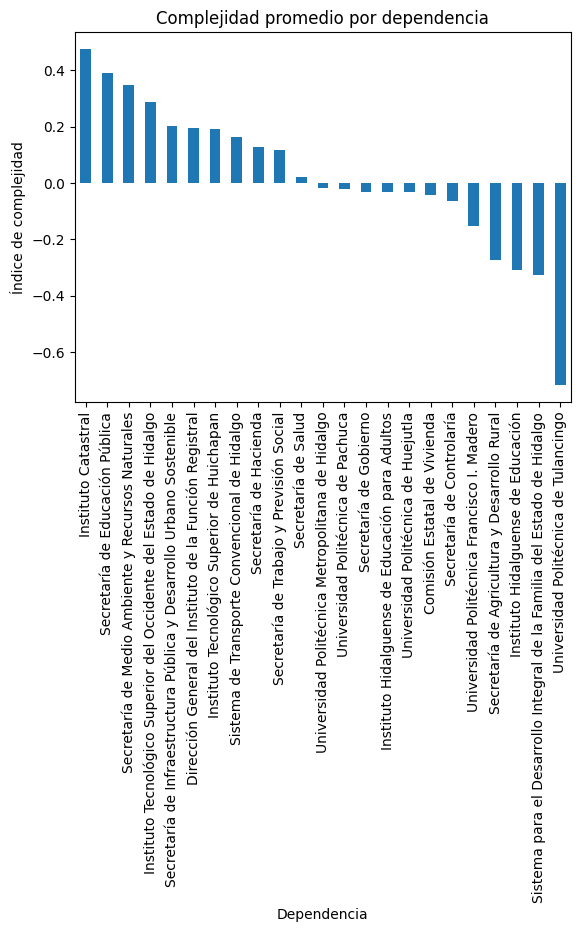

In [132]:
resumen_filtrado["mean"].plot(kind="bar")
plt.title("Complejidad promedio por dependencia")
plt.ylabel("Índice de complejidad")
plt.show()

Así como las dependencias con mayor número de trámites complejos.

In [133]:
top = df.sort_values("indice_z", ascending=False).head(50)
top["Dependencia"].value_counts()

Dependencia
Secretaría de Educación Pública                                            6
Secretaría de Hacienda                                                     5
Instituto Catastral                                                        5
Secretaría de Medio Ambiente y Recursos Naturales                          4
Secretaría de Infraestructura Pública y Desarrollo Urbano Sostenible       4
Universidad Politécnica de Pachuca                                         3
Dirección General del Instituto de la Función Registral                    3
Secretaría de Seguridad Pública                                            2
Sistema de Transporte Convencional de Hidalgo                              2
Instituto Hidalguense de Educación para Adultos                            2
Sistema de Transporte Masivo de Hidalgo                                    1
Instituto Hidalguense de Educación                                         1
Universidad Intercultural del Estado de Hidalgo                 

Finalmente, exportar los trámites con su correspondiente cluster y complejidad.

In [134]:
df_export = df[[
    "Tramite",
    "Secretaria",
    "Dependencia",
    "Tiempo_en_minutos",
    "CONTEO_NETO",
    "N_FORMATOS_FINAL",
    "nivel_digitalizacion",
    "costo",
    "cluster",
    "indice_z"
]]

df_export.to_csv("tramites_clusters.csv", index=False)